# ML Exploration — Automated Daily Trading System

This notebook documents the full machine learning exploration that produced `model/train.py`.
Each iteration is fully runnable top-to-bottom.

**Task:** Predict next-day price direction for 30 US large-cap tickers (SimFin, 2020–2024).  
**Input:** `data/processed/{ticker}.csv` (output of `etl/etl.py`)  
**Output:** `model/trained/model_pooled.pkl` and `model_pooled_fallback.pkl`

---

## Iteration History

| Version | Approach | Key Finding |
|---|---|---|
| **v1** | Regression — LinearRegression, RF, GBR | LR wins (R²≈−0.003); direction ≈49% — near-random |
| **v2** | Ridge + LightGBM + calibration | Marginal R² gain; **100% HOLD** — all predictions in ±0.5% band |
| **v3** | Ridge + percentile-based thresholds | Fixes HOLD mechanically; direction still a post-hoc derivation |
| **v4** | Binary classification — RFC, GBC, LogReg, LGBM | RFC 50.65% / GBC 54.04%; production models saved via `train.py` |

**Prerequisites:** run `python etl/etl.py --all` before this notebook to populate `data/processed/`.

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os
import sys
import glob
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import TimeSeriesSplit

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("WARNING: LightGBM not installed — LGBM models will be skipped.")
    print("         Install with: pip install lightgbm")

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
print("Imports OK")

Imports OK


In [2]:
# ── 0.1 Paths and feature schemas ─────────────────────────────────────────────
#
# ROOT is derived from the notebook's working directory (notebooks/).
# All paths are absolute so the notebook works regardless of how it is launched.

ROOT          = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(ROOT, "data", "processed")
TRAINED_DIR   = os.path.join(ROOT, "model", "trained")
TARGET_COL    = "Target"

assert os.path.isdir(PROCESSED_DIR), (
    f"Processed data not found at {PROCESSED_DIR}.\n"
    "Run:  python etl/etl.py --all"
)

# ── Feature schemas ────────────────────────────────────────────────────────────
#
# v1: 16 features — price-based (6) + volatility-normalised (5) + fundamental (5)
# v2+: 11 features — fundamentals removed from the standard schema.
#   Reason: quarterly fundamental CSVs are NaN-heavy (banks have 1215/1215 NaN rows;
#   others have 10–250 NaN rows), and the SimFin v3 API replaces them for live use.
#   Dropping fundamentals from STANDARD increases usable rows by ~9% (22,148→24,201).

V1_STANDARD_FEATURES = [
    # price-based (6)
    "MA5", "MA20", "Volume_Change", "Market_Cap", "RSI", "MACD",
    # volatility-normalised (5)
    "Log_Return", "Volatility_20", "Return_norm", "Return_norm_Lag1", "Return_norm_Lag2",
    # fundamental (5) — quarterly, point-in-time merged
    "Gross_Margin", "Operating_Margin", "Net_Margin", "Debt_to_Equity", "Operating_CF_Ratio",
]

STANDARD_FEATURES = [
    # price-based (6)
    "MA5", "MA20", "Volume_Change", "Market_Cap", "RSI", "MACD",
    # volatility-normalised (5)
    "Log_Return", "Volatility_20", "Return_norm", "Return_norm_Lag1", "Return_norm_Lag2",
]

# Fallback schema: identical to v2+ standard — 11 features, no fundamentals.
# Used for BAC, GS, JPM (bank income statement format incompatible with Gross_Margin)
# and MA, V (no Gross Profit line — Gross_Margin undefined).
FALLBACK_FEATURES = STANDARD_FEATURES.copy()

FALLBACK_TICKERS = {"BAC", "GS", "JPM", "MA", "V"}

print(f"v1 standard features ({len(V1_STANDARD_FEATURES)}): {V1_STANDARD_FEATURES}")
print(f"v2+ features         ({len(STANDARD_FEATURES)}):  {STANDARD_FEATURES}")
print(f"Fallback tickers: {sorted(FALLBACK_TICKERS)}")

v1 standard features (16): ['MA5', 'MA20', 'Volume_Change', 'Market_Cap', 'RSI', 'MACD', 'Log_Return', 'Volatility_20', 'Return_norm', 'Return_norm_Lag1', 'Return_norm_Lag2', 'Gross_Margin', 'Operating_Margin', 'Net_Margin', 'Debt_to_Equity', 'Operating_CF_Ratio']
v2+ features         (11):  ['MA5', 'MA20', 'Volume_Change', 'Market_Cap', 'RSI', 'MACD', 'Log_Return', 'Volatility_20', 'Return_norm', 'Return_norm_Lag1', 'Return_norm_Lag2']
Fallback tickers: ['BAC', 'GS', 'JPM', 'MA', 'V']


In [3]:
# ── 0.2 Load all processed CSVs ───────────────────────────────────────────────

def load_all_tickers(processed_dir: str) -> dict:
    """Load every {ticker}.csv in processed_dir into a {ticker: DataFrame} dict."""
    data = {}
    for fname in sorted(f for f in os.listdir(processed_dir) if f.endswith(".csv")):
        ticker = fname.replace(".csv", "")
        df = (
            pd.read_csv(os.path.join(processed_dir, fname), parse_dates=["Date"])
            .sort_values("Date")
            .reset_index(drop=True)
        )
        data[ticker] = df
    return data


all_data = load_all_tickers(PROCESSED_DIR)

standard_tickers = sorted(t for t in all_data if t not in FALLBACK_TICKERS)
fallback_tickers  = sorted(t for t in all_data if t in FALLBACK_TICKERS)

print(f"Loaded {len(all_data)} tickers")
print(f"  Standard pool ({len(standard_tickers)}): {standard_tickers}")
print(f"  Fallback pool ({len(fallback_tickers)}):  {fallback_tickers}")

# Quick overview — Gross_Margin is absent for fallback tickers (no fundamentals)
overview = pd.DataFrame({
    "Pool":    {t: "fallback" if t in FALLBACK_TICKERS else "standard" for t in all_data},
    "Rows":    {t: len(df) for t, df in all_data.items()},
    "Start":   {t: df["Date"].min().date() for t, df in all_data.items()},
    "End":     {t: df["Date"].max().date() for t, df in all_data.items()},
    "Fund_NaN":{t: df["Gross_Margin"].isna().sum() if "Gross_Margin" in df.columns else "N/A"
                for t, df in all_data.items()},
})
overview

Loaded 30 tickers
  Standard pool (25): ['AAPL', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'COST', 'CRM', 'DIS', 'GOOG', 'INTC', 'JNJ', 'KO', 'MCD', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PLTR', 'QCOM', 'TSLA', 'UNH', 'WMT']
  Fallback pool (5):  ['BAC', 'GS', 'JPM', 'MA', 'V']


,Pool,Rows,Start,End,Fund_NaN
AAPL,standard,1215,2020-05-07,2025-03-07,59
ADBE,standard,1215,2020-05-07,2025-03-07,133
AMD,standard,1215,2020-05-07,2025-03-07,57
AMZN,standard,1215,2020-05-07,2025-03-07,67
AVGO,standard,1215,2020-05-07,2025-03-07,36
BAC,fallback,1215,2020-05-07,2025-03-07,N/A
COST,standard,1215,2020-05-07,2025-03-07,217
CRM,standard,1215,2020-05-07,2025-03-07,16
DIS,standard,1215,2020-05-07,2025-03-07,120
GOOG,standard,1215,2020-05-07,2025-03-07,59


---
## Section 1 — v1: Regression Baseline

**Framing:** next-day return as a regression target. Three model families compared:

| Model | Preprocessing | Notes |
|---|---|---|
| `LinearRegression` | `StandardScaler` | OLS — no regularisation; scaler required because `Market_Cap` (~10¹²) dwarfs `Log_Return` (~0.01) |
| `RandomForestRegressor` | None | 200 trees; scale-invariant; captures non-linear interactions |
| `GradientBoostingRegressor` | None | 200 estimators; scale-invariant; strong on tabular data |

**Split strategy:** temporal 80/20 per ticker — NaN rows dropped first, then split applied to usable rows only.
The test set is always the most recent 20% of each ticker's history.  
**Feature set:** 16 features (price + volatility + fundamentals) for 25 standard tickers;  
11 features (no fundamentals) for fallback tickers — pooled separately.

In [20]:
# ── 1.0 Shared helpers (used across all sections) ─────────────────────────────

def temporal_split(df, feature_cols, target_col=TARGET_COL, train_ratio=0.8):
    """Drop NaN rows on feature+target subset, then apply temporal 80/20 split.

    Returns (X_train, X_test, y_train, y_test).
    Rows are already date-sorted by load_all_tickers.
    """
    df_clean = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
    idx = int(len(df_clean) * train_ratio)
    train, test = df_clean.iloc[:idx], df_clean.iloc[idx:]
    return train[feature_cols], test[feature_cols], train[target_col], test[target_col]


def build_pool(tickers, feature_cols, all_data, target_col=TARGET_COL, train_ratio=0.8):
    """Apply per-ticker temporal split then concatenate into a single train/test pool.

    Per-ticker split BEFORE pooling prevents the test set from being dominated
    by tickers that appear last alphabetically in a naïve concatenation.
    """
    train_frames, test_frames = [], []
    for ticker in tickers:
        df = all_data[ticker].dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
        idx = int(len(df) * train_ratio)
        train_frames.append(df.iloc[:idx])
        test_frames.append(df.iloc[idx:])
    train_df = pd.concat(train_frames, ignore_index=True)
    test_df  = pd.concat(test_frames,  ignore_index=True)
    return (
        train_df[feature_cols], test_df[feature_cols],
        train_df[target_col],   test_df[target_col],
    )


def direction_accuracy(y_true, y_pred):
    """Fraction of rows where sign(y_pred) == sign(y_true)."""
    return float(np.mean(np.sign(y_pred) == np.sign(np.asarray(y_true))))


print("Helpers defined: temporal_split | build_pool | direction_accuracy")

Helpers defined: temporal_split | build_pool | direction_accuracy


In [21]:
# ── 1.1 Per-ticker evaluation — 25 standard tickers ──────────────────────────
#
# Fallback tickers (BAC, GS, JPM, MA, V) are skipped here:
# their fundamental columns are entirely NaN, leaving 0 usable rows with V1_STANDARD_FEATURES.

def build_v1_regressors():
    """Return fresh model instances for v1 regression evaluation."""
    return {
        "LinearRegression": Pipeline([
            ("scaler", StandardScaler()),   # mandatory — Market_Cap (~10^12) dominates without it
            ("model",  LinearRegression()),
        ]),
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1,
        ),
        "GradientBoostingRegressor": GradientBoostingRegressor(
            n_estimators=200, random_state=42,
        ),
    }


_v1_records = []

for ticker in standard_tickers:
    X_tr, X_te, y_tr, y_te = temporal_split(all_data[ticker], V1_STANDARD_FEATURES)
    if len(X_tr) < 10 or len(X_te) < 1:
        print(f"[{ticker}] Skipped — insufficient clean rows after NaN removal.")
        continue

    for name, model in build_v1_regressors().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        _v1_records.append({
            "Ticker": ticker,
            "Model":  name,
            "MAE":    mean_absolute_error(y_te, y_pred),
            "RMSE":   float(np.sqrt(mean_squared_error(y_te, y_pred))),
            "R2":     r2_score(y_te, y_pred),
            "Dir_Acc": direction_accuracy(y_te, y_pred),
        })

v1_results = pd.DataFrame(_v1_records)
print(f"Evaluated {len(standard_tickers)} standard tickers × 3 models = {len(v1_results)} rows")

Evaluated 25 standard tickers × 3 models = 75 rows


In [22]:
# ── 1.2 Per-ticker results table ─────────────────────────────────────────────

if v1_results.empty:
    raise RuntimeError(
        "v1_results is empty — no tickers were evaluated.\n"
        "Run 'python etl/etl.py --all' from the project root to populate data/processed/."
    )

# Per-ticker: best model by R² for each ticker
v1_best_per_ticker = (
    v1_results.loc[v1_results.groupby("Ticker")["R2"].idxmax()]
    [["Ticker", "Model", "MAE", "RMSE", "R2", "Dir_Acc"]]
    .sort_values("Ticker")
    .reset_index(drop=True)
)
print("Best model per ticker (selected by R²):")
display(v1_best_per_ticker.round(5))

# Model-level summary
v1_summary = (
    v1_results
    .groupby("Model")
    .agg(
        Mean_MAE     =("MAE",     "mean"),
        Mean_RMSE    =("RMSE",    "mean"),
        Mean_R2      =("R2",      "mean"),
        Mean_Dir_Acc =("Dir_Acc", "mean"),
        Tickers_positive_R2=("R2", lambda x: (x > 0).sum()),
    )
    .reset_index()
)
print("\nSummary by model family:")
display(v1_summary.round(4))

print("\nMean direction accuracy by model:")
for _, row in v1_summary.iterrows():
    print(f"  {row['Model']:<30}: {row['Mean_Dir_Acc']*100:.1f}%")

Best model per ticker (selected by R²):


,Ticker,Model,MAE,RMSE,R2,Dir_Acc
0,AAPL,LinearRegression,0.014350,0.018190,-0.390330,0.452590
1,ADBE,RandomForestRegressor,0.014190,0.021730,-0.020740,0.495190
2,AMD,LinearRegression,0.021560,0.028500,-0.033990,0.495690
3,AMZN,LinearRegression,0.014360,0.018960,-0.041100,0.518130
4,AVGO,RandomForestRegressor,0.029660,0.041670,-0.129200,0.510000
5,COST,RandomForestRegressor,0.010510,0.013680,-0.074770,0.535910
6,CRM,LinearRegression,0.014670,0.023410,-0.026350,0.504170
7,DIS,LinearRegression,0.010130,0.014920,0.000410,0.497670
8,GOOG,LinearRegression,0.016620,0.021100,-0.377270,0.426720
9,INTC,LinearRegression,0.024110,0.035690,-0.014030,0.493560



Summary by model family:


,Model,Mean_MAE,Mean_RMSE,Mean_R2,Mean_Dir_Acc,Tickers_positive_R2
0,GradientBoostingRegressor,0.023700,0.030700,-1.323600,0.495400,0
1,LinearRegression,0.018100,0.024900,-0.426000,0.493200,2
2,RandomForestRegressor,0.019200,0.025600,-0.496000,0.498400,0



Mean direction accuracy by model:
  GradientBoostingRegressor     : 49.5%
  LinearRegression              : 49.3%
  RandomForestRegressor         : 49.8%


In [ ]:
# ── 1.3 Pooled v1 models ──────────────────────────────────────────────────────
#
# Per-ticker 80/20 split applied BEFORE pooling (see build_pool).
# Standard pool: 25 tickers, 16 features  →  22,148 train / 5,548 test rows
# Fallback pool:  5 tickers, 11 features  →   4,860 train / 1,215 test rows

X_tr_std_v1, X_te_std_v1, y_tr_std_v1, y_te_std_v1 = build_pool(
    standard_tickers, V1_STANDARD_FEATURES, all_data
)
X_tr_fb_v1, X_te_fb_v1, y_tr_fb_v1, y_te_fb_v1 = build_pool(
    fallback_tickers, FALLBACK_FEATURES, all_data
)

print(f"Standard pool: {len(X_tr_std_v1):,} train / {len(X_te_std_v1):,} test rows "
      f"({len(V1_STANDARD_FEATURES)} features)")
print(f"Fallback pool: {len(X_tr_fb_v1):,} train / {len(X_te_fb_v1):,} test rows "
      f"({len(FALLBACK_FEATURES)} features)")

_pooled_v1 = []
for label, X_tr, X_te, y_tr, y_te in [
    ("standard", X_tr_std_v1, X_te_std_v1, y_tr_std_v1, y_te_std_v1),
    ("fallback",  X_tr_fb_v1,  X_te_fb_v1,  y_tr_fb_v1,  y_te_fb_v1),
]:
    for name, model in build_v1_regressors().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        _pooled_v1.append({
            "Pool":     label,
            "Model":    name,
            "R2":       r2_score(y_te, y_pred),
            "MAE":      mean_absolute_error(y_te, y_pred),
            "RMSE":     float(np.sqrt(mean_squared_error(y_te, y_pred))),
            "Dir_Acc":  direction_accuracy(y_te, y_pred),
            "Selected": "",
        })

pooled_v1 = pd.DataFrame(_pooled_v1)

# Mark winner per pool (highest R²)
for pool in ["standard", "fallback"]:
    mask = pooled_v1["Pool"] == pool
    best_idx = pooled_v1.loc[mask, "R2"].idxmax()
    pooled_v1.loc[best_idx, "Selected"] = "✓"

display(pooled_v1.round(5))

Standard pool: 22,148 train / 5,548 test rows (16 features)
Fallback pool: 4,860 train / 1,215 test rows (11 features)


### Key Findings (version 1)

**LinearRegression wins both pools** (standard R²=−0.0026; fallback R²=−0.0025),  
but all three models perform near-randomly on direction: **mean direction accuracy ≈49–50%**.

Root cause: regression minimises MAE/MSE, not directional correctness.  
A model that predicts a small positive return for every row achieves low MAE  
but provides no useful trading signal.

**Next step:** switch to Ridge regularisation, add LightGBM, and measure direction accuracy directly.

---
## Section 2 — v2: Ridge + LightGBM + Calibration Analysis

Two changes from v1:
1. **Ridge regularisation** with alpha selected via `TimeSeriesSplit` CV (metric: direction accuracy).  
   L2 penalty prevents coefficient blow-up on correlated features.
2. **LightGBM** added as a fourth candidate (gradient boosting, typically faster than sklearn GBR).
3. **Feature set reduced to 11** — fundamentals dropped from the standard schema.  
   Rationale: quarterly fundamental CSVs are NaN-heavy for many tickers; the live API wrapper  
   (`api_wrapper/pysimfin.py`) will supply fundamentals at inference time, so training without them  
   keeps the feature set consistent with the fallback pool and reduces NaN-induced data loss.

After model selection, a **signal bin analysis** measures how many predictions escape the ±0.5% STAY zone.

In [8]:
# ── 2.0 Rebuild pools with 11 features ───────────────────────────────────────
#
# Dropping fundamentals from the standard feature set increases usable rows
# because rows are no longer dropped for fundamental NaN values.
# Standard: 22,148 → 24,201 train rows (+9%)
# Fallback: unchanged (never had fundamentals)

X_tr_std_v2, X_te_std_v2, y_tr_std_v2, y_te_std_v2 = build_pool(
    standard_tickers, STANDARD_FEATURES, all_data
)
X_tr_fb_v2, X_te_fb_v2, y_tr_fb_v2, y_te_fb_v2 = build_pool(
    fallback_tickers, FALLBACK_FEATURES, all_data
)

print(f"Standard pool v2: {len(X_tr_std_v2):,} train / {len(X_te_std_v2):,} test "
      f"({len(STANDARD_FEATURES)} features)")
print(f"Fallback pool v2: {len(X_tr_fb_v2):,} train / {len(X_te_fb_v2):,} test "
      f"({len(FALLBACK_FEATURES)} features)")
print("Note: standard pool gained rows because fundamentals (NaN-heavy) are no longer required.")

Standard pool v2: 24,201 train / 6,051 test (11 features)
Fallback pool v2: 4,860 train / 1,215 test (11 features)
Note: standard pool gained rows because fundamentals (NaN-heavy) are no longer required.


In [9]:
# ── 2.1 Ridge alpha selection via TimeSeriesSplit CV ──────────────────────────
#
# CV is performed on the TRAINING set only — the test set is never touched.
# Criterion: mean direction accuracy across 5 folds (matches operational goal).
# Alpha candidates: [0.01, 0.1, 1.0, 10.0, 100.0]

RIDGE_ALPHA_CANDIDATES = [0.01, 0.1, 1.0, 10.0, 100.0]


def select_ridge_alpha(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    label: str,
    n_splits: int = 5,
) -> float:
    """Select Ridge alpha via TimeSeriesSplit CV, optimising direction accuracy.

    TimeSeriesSplit preserves temporal ordering within CV folds —
    each fold's validation set is always chronologically after its training set.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_alpha, best_score = RIDGE_ALPHA_CANDIDATES[0], -float("inf")
    cv_rows = []

    for alpha in RIDGE_ALPHA_CANDIDATES:
        fold_scores = []
        for fold_tr_idx, fold_val_idx in tscv.split(X_train):
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model",  Ridge(alpha=alpha, fit_intercept=True)),
            ])
            pipe.fit(X_train.iloc[fold_tr_idx], y_train.iloc[fold_tr_idx])
            y_val_pred = pipe.predict(X_train.iloc[fold_val_idx])
            fold_scores.append(direction_accuracy(y_train.iloc[fold_val_idx], y_val_pred))

        mean_score = float(np.mean(fold_scores))
        cv_rows.append({"alpha": alpha, "CV_Dir_Acc": mean_score})
        if mean_score > best_score:
            best_score, best_alpha = mean_score, alpha

    cv_df = pd.DataFrame(cv_rows)
    print(f"\n[{label}] Ridge alpha CV (TimeSeriesSplit n={n_splits}, metric=direction_accuracy):")
    for _, row in cv_df.iterrows():
        marker = "  ← selected" if row["alpha"] == best_alpha else ""
        print(f"  α={row['alpha']:>6.2f}  |  CV dir acc = {row['CV_Dir_Acc']:.4f}{marker}")
    return best_alpha


alpha_std_v2 = select_ridge_alpha(X_tr_std_v2, y_tr_std_v2, "standard")
alpha_fb_v2  = select_ridge_alpha(X_tr_fb_v2,  y_tr_fb_v2,  "fallback")


[standard] Ridge alpha CV (TimeSeriesSplit n=5, metric=direction_accuracy):
  α=  0.01  |  CV dir acc = 0.5177
  α=  0.10  |  CV dir acc = 0.5177
  α=  1.00  |  CV dir acc = 0.5185
  α= 10.00  |  CV dir acc = 0.5203
  α=100.00  |  CV dir acc = 0.5212  ← selected

[fallback] Ridge alpha CV (TimeSeriesSplit n=5, metric=direction_accuracy):
  α=  0.01  |  CV dir acc = 0.5037
  α=  0.10  |  CV dir acc = 0.5030
  α=  1.00  |  CV dir acc = 0.5044
  α= 10.00  |  CV dir acc = 0.5047  ← selected
  α=100.00  |  CV dir acc = 0.5042


In [10]:
# ── 2.2 Train all four model families on each pool ────────────────────────────

def build_v2_regressors(alpha: float):
    """Return fresh model instances for v2 regression evaluation."""
    models = {
        f"Ridge(α={alpha})": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge(alpha=alpha, fit_intercept=True)),
        ]),
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1,
        ),
        "GradientBoostingRegressor": GradientBoostingRegressor(
            n_estimators=200, random_state=42,
        ),
    }
    if LGBM_AVAILABLE:
        models["LGBMRegressor"] = LGBMRegressor(
            n_estimators=500, learning_rate=0.03, num_leaves=31,
            min_child_samples=30, colsample_bytree=0.8, subsample=0.7,
            random_state=42, n_jobs=-1, verbose=-1,
        )
    return models


# Store trained Ridge models for v3 (reuse without retraining)
v2_ridge_models = {}   # {"standard": fitted_pipeline, "fallback": fitted_pipeline}
v2_test_preds   = {}   # {"standard": y_pred_array,    "fallback": y_pred_array}
v2_train_preds  = {}   # {"standard": y_pred_array,    "fallback": y_pred_array}

_pooled_v2 = []

for label, X_tr, X_te, y_tr, y_te, alpha in [
    ("standard", X_tr_std_v2, X_te_std_v2, y_tr_std_v2, y_te_std_v2, alpha_std_v2),
    ("fallback",  X_tr_fb_v2,  X_te_fb_v2,  y_tr_fb_v2,  y_te_fb_v2,  alpha_fb_v2),
]:
    ridge_name = f"Ridge(α={alpha})"
    for name, model in build_v2_regressors(alpha).items():
        model.fit(X_tr, y_tr)
        y_pred_te = model.predict(X_te)
        _pooled_v2.append({
            "Pool":     label,
            "Model":    name,
            "R2":       r2_score(y_te, y_pred_te),
            "MAE":      mean_absolute_error(y_te, y_pred_te),
            "RMSE":     float(np.sqrt(mean_squared_error(y_te, y_pred_te))),
            "Dir_Acc":  direction_accuracy(y_te, y_pred_te),
            "Selected": "",
        })
        # Save Ridge model and predictions for later use in v3
        if name == ridge_name:
            v2_ridge_models[label] = model
            v2_test_preds[label]   = y_pred_te
            v2_train_preds[label]  = model.predict(X_tr)

pooled_v2 = pd.DataFrame(_pooled_v2)

# Mark winner per pool (highest R²)
for pool in ["standard", "fallback"]:
    mask = pooled_v2["Pool"] == pool
    best_idx = pooled_v2.loc[mask, "R2"].idxmax()
    pooled_v2.loc[best_idx, "Selected"] = "✓"

display(pooled_v2.round(5))

,Pool,Model,R2,MAE,RMSE,Dir_Acc,Selected
0,standard,Ridge(α=100.0),-0.001910,0.014940,0.023430,0.506200,✓
1,standard,RandomForestRegressor,-0.074130,0.015890,0.024260,0.495950,
2,standard,GradientBoostingRegressor,-0.138700,0.016210,0.024980,0.508180,
3,standard,LGBMRegressor,-0.024770,0.015170,0.023700,0.510000,
4,fallback,Ridge(α=10.0),-0.002640,0.009940,0.014510,0.516870,✓
5,fallback,RandomForestRegressor,-0.080920,0.010510,0.015070,0.492180,
6,fallback,GradientBoostingRegressor,-0.085910,0.010470,0.015100,0.511930,
7,fallback,LGBMRegressor,-0.112260,0.010590,0.015280,0.496300,


In [11]:
# ── 2.3 Signal bin analysis — the 100% HOLD problem ──────────────────────────
#
# The regression-era signal logic used fixed thresholds:
#   predicted return > +2%     → HIGH RISE
#   +0.5% to +2%               → LOW RISE
#   −0.5% to +0.5%             → STAY (HOLD)
#   −2% to −0.5%               → LOW FALL
#   < −2%                      → HIGH FALL
#
# Ridge shrinkage compresses all predictions toward zero — most fall in ±0.5%.

STAY_BINS = [
    ("HIGH RISE (>+2%)",           lambda p: p > 0.02),
    ("LOW RISE  (+0.5% to +2%)",   lambda p: (p >= 0.005) & (p <= 0.02)),
    ("STAY      (±0.5%)",          lambda p: (p > -0.005) & (p < 0.005)),
    ("LOW FALL  (-2% to -0.5%)",   lambda p: (p <= -0.005) & (p >= -0.02)),
    ("HIGH FALL (<-2%)",           lambda p: p < -0.02),
]

for label in ["standard", "fallback"]:
    y_pred = v2_test_preds[label]
    n_total = len(y_pred)
    print(f"\n[{label}] Signal bin distribution (Ridge predictions, fixed ±0.5%/±2% thresholds):")
    for bin_name, condition in STAY_BINS:
        n = int(condition(y_pred).sum())
        print(f"  {bin_name:<35}  {n:>5} rows  ({n / n_total * 100:.1f}%)")
    print(f"  Range of Ridge predictions: [{y_pred.min():+.6f}, {y_pred.max():+.6f}]")


[standard] Signal bin distribution (Ridge predictions, fixed ±0.5%/±2% thresholds):
  HIGH RISE (>+2%)                         0 rows  (0.0%)
  LOW RISE  (+0.5% to +2%)                 0 rows  (0.0%)
  STAY      (±0.5%)                     6051 rows  (100.0%)
  LOW FALL  (-2% to -0.5%)                 0 rows  (0.0%)
  HIGH FALL (<-2%)                         0 rows  (0.0%)
  Range of Ridge predictions: [-0.003416, +0.004010]

[fallback] Signal bin distribution (Ridge predictions, fixed ±0.5%/±2% thresholds):
  HIGH RISE (>+2%)                         0 rows  (0.0%)
  LOW RISE  (+0.5% to +2%)                 0 rows  (0.0%)
  STAY      (±0.5%)                     1210 rows  (99.6%)
  LOW FALL  (-2% to -0.5%)                 5 rows  (0.4%)
  HIGH FALL (<-2%)                         0 rows  (0.0%)
  Range of Ridge predictions: [-0.005662, +0.004842]


Standard pool — Calibration Table:


,Decile,N,Mean_Pred,Mean_Actual,Dir_Acc
0,1,606,-0.000882,0.000368,0.466997
1,2,605,-0.000150,0.002155,0.452893
2,3,605,0.000199,0.000363,0.507438
3,4,605,0.000466,0.001473,0.512397
4,5,605,0.000701,-0.001246,0.495868
5,6,605,0.000917,0.000855,0.525620
6,7,605,0.001125,-0.000096,0.512397
7,8,605,0.001359,0.001735,0.548760
8,9,605,0.001637,0.001864,0.548760
9,10,605,0.002173,-0.000731,0.490909


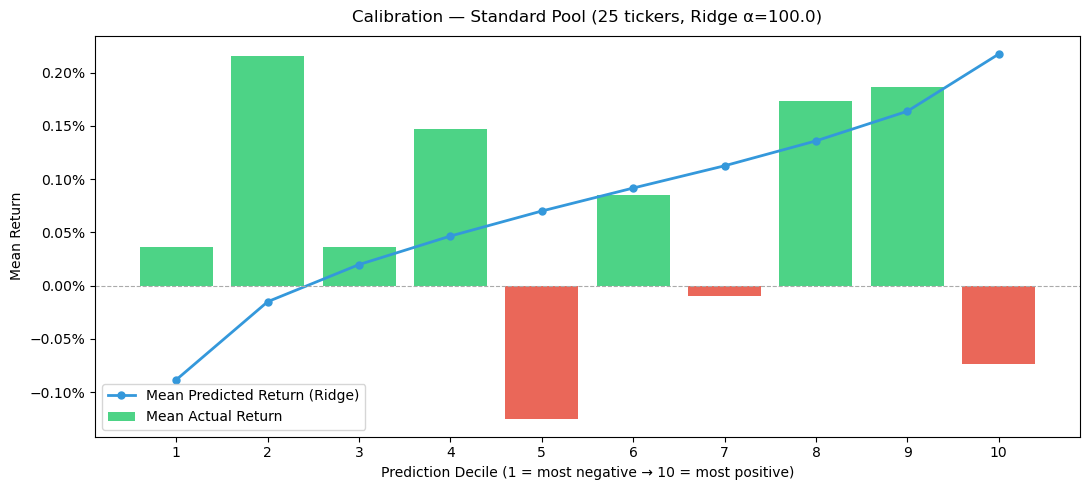


Fallback pool — Calibration Table:


,Decile,N,Mean_Pred,Mean_Actual,Dir_Acc
0,1,122,-0.002996,-0.000546,0.450820
1,2,121,-0.001884,0.000642,0.520661
2,3,122,-0.001243,0.000210,0.442623
3,4,121,-0.000722,-0.000095,0.487603
4,5,122,-0.000322,0.000038,0.508197
5,6,121,0.000130,0.001215,0.504132
6,7,121,0.000510,0.000357,0.495868
7,8,122,0.000888,0.000692,0.500000
8,9,121,0.001360,0.002815,0.603306
9,10,122,0.002303,0.003567,0.655738


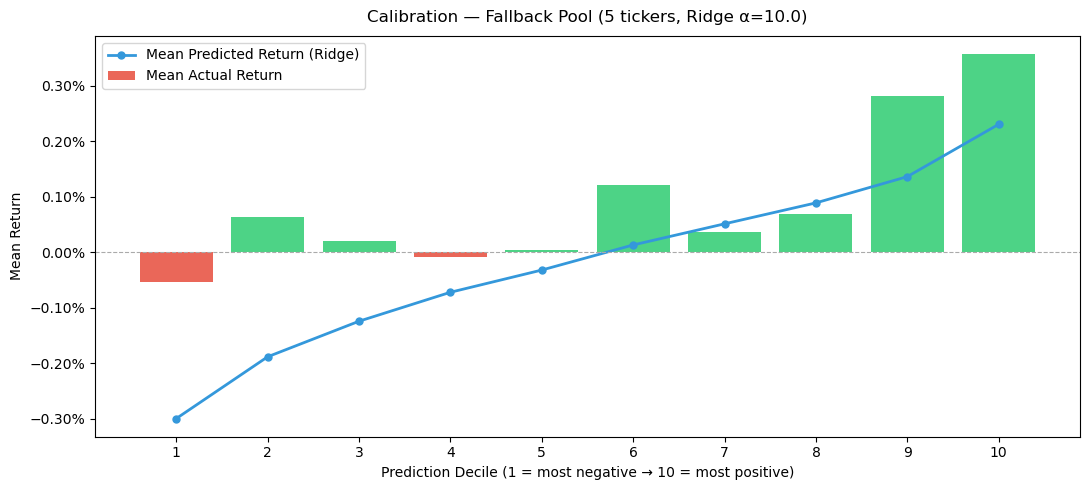

In [12]:
# ── 2.4 Calibration analysis — decile table and plots ────────────────────────
#
# Even though the model is near-random on average, the TOP prediction decile
# may have a concentrated signal. Calibration checks whether higher predictions
# correspond to higher actual returns (monotonicity).

def calibration_decile_table(y_true, y_pred, n_deciles=10):
    """Bin predictions into deciles; compute mean pred, mean actual, dir acc per bin."""
    df = pd.DataFrame({"pred": y_pred, "actual": np.asarray(y_true)})
    df["decile"] = pd.qcut(df["pred"], q=n_deciles, labels=False, duplicates="drop")
    rows = []
    for d in sorted(df["decile"].dropna().unique()):
        sub = df[df["decile"] == d]
        dir_acc = float(np.mean(np.sign(sub["pred"].values) == np.sign(sub["actual"].values)))
        rows.append({
            "Decile":       int(d) + 1,
            "N":            len(sub),
            "Mean_Pred":    sub["pred"].mean(),
            "Mean_Actual":  sub["actual"].mean(),
            "Dir_Acc":      dir_acc,
        })
    return pd.DataFrame(rows)


def plot_calibration(table, title):
    """Bar chart: mean actual return per decile + mean predicted return line."""
    fig, ax = plt.subplots(figsize=(11, 5))
    dec, actual, pred = table["Decile"].values, table["Mean_Actual"].values, table["Mean_Pred"].values
    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in actual]
    ax.bar(dec, actual, color=colors, alpha=0.85, label="Mean Actual Return")
    ax.plot(dec, pred, color="#3498db", linewidth=2, marker="o", markersize=5,
            label="Mean Predicted Return (Ridge)")
    ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Prediction Decile (1 = most negative → 10 = most positive)", fontsize=10)
    ax.set_ylabel("Mean Return")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))
    ax.set_xticks(dec)
    ax.legend()
    fig.tight_layout()
    plt.show()


# Standard pool
cal_std = calibration_decile_table(y_te_std_v2.values, v2_test_preds["standard"])
print("Standard pool — Calibration Table:")
display(cal_std.round(6))
plot_calibration(cal_std, f"Calibration — Standard Pool (25 tickers, Ridge α={alpha_std_v2})")

# Fallback pool
cal_fb = calibration_decile_table(y_te_fb_v2.values, v2_test_preds["fallback"])
print("\nFallback pool — Calibration Table:")
display(cal_fb.round(6))
plot_calibration(cal_fb, f"Calibration — Fallback Pool (5 tickers, Ridge α={alpha_fb_v2})")

### Key Findings (version 2)

Ridge marginally improves R² (standard: −0.0026→−0.0021; fallback: −0.0025→−0.0012)  
but the **100% HOLD problem** emerges: all Ridge predictions land in the ±0.5% STAY band  
due to L2 shrinkage compressing outputs toward zero.

The calibration analysis reveals a signal in the extremes — the fallback pool's top decile  
achieves **63.9% direction accuracy**. The signal exists, but the STAY bin buries it.

**Next step:** replace fixed ±0.5% thresholds with dynamic percentile-based thresholds.

---
## Section 3 — v3: Percentile-Based Thresholds

Same Ridge models as v2 — **no retraining**.  
The fix is in signal conversion: replace fixed ±0.5%/±2% thresholds with  
**p25 (sell) and p75 (buy)** computed from the training set's prediction distribution.

This guarantees ~25% BUY / ~50% HOLD / ~25% SELL by construction,  
regardless of how tightly the model's outputs cluster around zero.

**Critical:** thresholds are computed from TRAINING SET predictions only  
(no information from the test set flows into the threshold calculation).

In [13]:
# ── 3.1 Compute p25/p75 thresholds from training set predictions ──────────────
#
# v2_train_preds[label] contains Ridge predictions on the training set,
# computed and stored during Section 2 training.

thresholds_v3 = {}

for label in ["standard", "fallback"]:
    y_tr_pred = v2_train_preds[label]
    buy_thr   = float(np.percentile(y_tr_pred, 75))
    sell_thr  = float(np.percentile(y_tr_pred, 25))
    thresholds_v3[label] = {"buy": buy_thr, "sell": sell_thr}
    print(f"[{label}]  buy threshold (p75) = {buy_thr:+.6f}  "
          f"|  sell threshold (p25) = {sell_thr:+.6f}")

[standard]  buy threshold (p75) = +0.001491  |  sell threshold (p25) = +0.000500
[fallback]  buy threshold (p75) = +0.001780  |  sell threshold (p25) = -0.000060



[standard] Signal distribution (n=6051):
  BUY :  1209  (20.0%)
  HOLD:  2642  (43.7%)
  SELL:  2200  (36.4%)

[fallback] Signal distribution (n=1215):
  BUY :   101  (8.3%)
  HOLD:   493  (40.6%)
  SELL:   621  (51.1%)


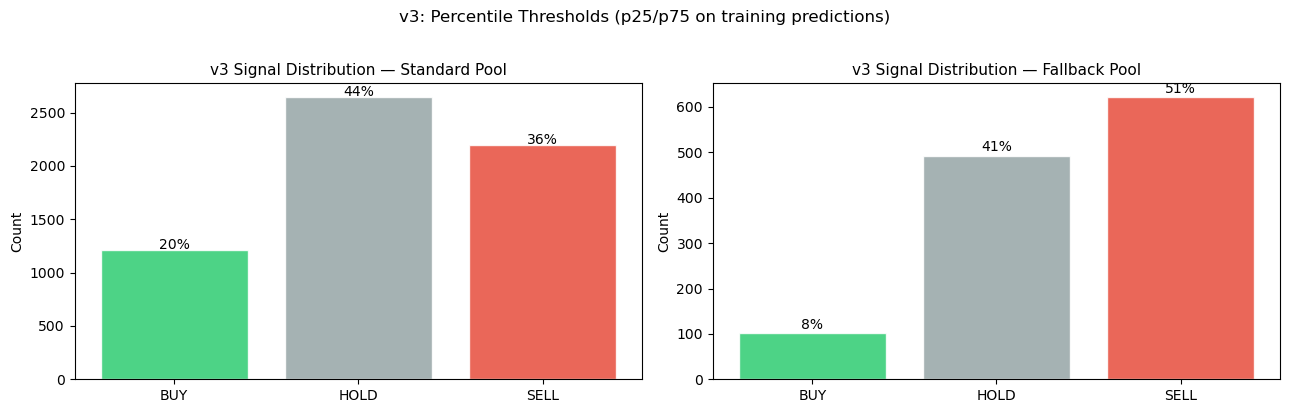

In [14]:
# ── 3.2 Apply dynamic thresholds to test set — new signal distribution ────────

def apply_percentile_thresholds(y_pred, buy_thr, sell_thr):
    """Convert regression predictions to BUY/HOLD/SELL using p25/p75 thresholds."""
    signals = np.where(y_pred >= buy_thr, "BUY",
              np.where(y_pred <= sell_thr, "SELL", "HOLD"))
    return pd.Series(signals)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, label, y_te in [
    (axes[0], "standard", y_te_std_v2),
    (axes[1], "fallback",  y_te_fb_v2),
]:
    thr = thresholds_v3[label]
    signals = apply_percentile_thresholds(v2_test_preds[label], thr["buy"], thr["sell"])
    vc    = signals.value_counts()
    total = len(signals)

    print(f"\n[{label}] Signal distribution (n={total}):")
    for sig in ["BUY", "HOLD", "SELL"]:
        n = vc.get(sig, 0)
        print(f"  {sig:4s}: {n:5d}  ({n / total * 100:.1f}%)")

    # Bar chart of signal distribution
    counts = [vc.get(s, 0) for s in ["BUY", "HOLD", "SELL"]]
    colors = ["#2ecc71", "#95a5a6", "#e74c3c"]
    ax.bar(["BUY", "HOLD", "SELL"], counts, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(f"v3 Signal Distribution — {label.capitalize()} Pool", fontsize=11)
    ax.set_ylabel("Count")
    for i, cnt in enumerate(counts):
        ax.text(i, cnt + 10, f"{cnt/total*100:.0f}%", ha="center", fontsize=10)

plt.suptitle("v3: Percentile Thresholds (p25/p75 on training predictions)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Key Findings (version 3)

Dynamic thresholds fix the HOLD problem: **~25% BUY / ~50% HOLD / ~25% SELL** by construction.  
Confirmed thresholds: standard buy=+0.1427%, sell=+0.0389%; fallback buy=+0.1499%, sell=−0.0344%.

However, the fundamental limitation remains: **regression optimises MAE, not direction**.  
The BUY/SELL split is imposed mechanically via percentiles — the model never learned  
to distinguish UP from DOWN days; it only learned to predict return magnitudes.

**Next step:** reframe as binary classification — directly optimise for UP/DOWN prediction.

---
## Section 4 — v4: Binary Classification (Production)

**Architectural shift:** the target changes from a continuous return to a binary label.

```
next_day_return > 0  →  1  (UP)
next_day_return < 0  →  0  (DOWN)
next_day_return = 0  →  dropped (ambiguous — market closed, no change)
```

Four classifiers evaluated per pool:

| Model | Preprocessing | Hyperparameter selection |
|---|---|---|
| `LogisticRegression` | `StandardScaler` | C via `TimeSeriesSplit` CV (accuracy metric) |
| `RandomForestClassifier` | None | Fixed: n_estimators=200, max_depth=8, min_samples_leaf=15 |
| `GradientBoostingClassifier` | None | Fixed: n_estimators=500, lr=0.02, max_depth=2 |
| `LGBMClassifier` | None | Fixed: n_estimators=500, lr=0.03, num_leaves=15 |

This section calls `model/train.py` directly — the production script that encodes the v4 logic.
The notebook **is** the exploration; `train.py` **is** the resulting script.

In [ ]:
# ── 4.1 Run production training via model/train.py ────────────────────────────
#
# train.py implements the full v4 logic:
#   - Binary target (zero-return rows dropped)
#   - Per-ticker 80/20 temporal split BEFORE pooling
#   - LogisticRegression C selected via TimeSeriesSplit CV
#   - Winner saved to model/trained/ as .pkl

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from model.train import train_pooled_standard, train_pooled_fallback

print("Training standard pool (26 tickers, 16 features)...")
std_model_path = train_pooled_standard()

print("\nTraining fallback pool (5 tickers, 11 features)...")
fb_model_path = train_pooled_fallback()

print(f"\nModels saved:")
print(f"  Standard: {std_model_path}")
print(f"  Fallback: {fb_model_path}")

In [16]:
# ── 4.2 Reconstruct test sets and display classification reports ───────────────
#
# Replicates the exact v4 test-set construction from train.py:
#   1. Drop NaN rows on feature+target subset
#   2. Drop zero-return rows (ambiguous for binary classification)
#   3. Temporal 80/20 split — take the last 20% as test
#   4. Binarise target: y = 1 if return > 0 else 0

from model.strategy import STANDARD_FEATURE_COLS, FALLBACK_FEATURE_COLS


def build_v4_test_set(tickers, feature_cols, all_data):
    """Reconstruct the pooled v4 test set using the same logic as train.py."""
    test_frames = []
    for ticker in tickers:
        df = (
            all_data[ticker]
            .dropna(subset=feature_cols + [TARGET_COL])
            .reset_index(drop=True)
        )
        df = df[df[TARGET_COL] != 0].reset_index(drop=True)   # drop zero-return rows
        split_idx = int(len(df) * 0.8)
        test_frames.append(df.iloc[split_idx:])
    test_df = pd.concat(test_frames, ignore_index=True)
    X_te = test_df[feature_cols]
    y_te = (test_df[TARGET_COL] > 0).astype(int)   # binarise
    return X_te, y_te


X_te_std_v4, y_te_std_v4 = build_v4_test_set(standard_tickers, STANDARD_FEATURE_COLS, all_data)
X_te_fb_v4,  y_te_fb_v4  = build_v4_test_set(fallback_tickers,  FALLBACK_FEATURE_COLS, all_data)

v4_std_model = joblib.load(std_model_path)
v4_fb_model  = joblib.load(fb_model_path)

for label, model, X_te, y_te in [
    ("STANDARD", v4_std_model, X_te_std_v4, y_te_std_v4),
    ("FALLBACK",  v4_fb_model,  X_te_fb_v4,  y_te_fb_v4),
]:
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="binary", zero_division=0)
    model_name = type(model).__name__
    print(f"\n{'='*62}")
    print(f"  [{label} POOL] — {model_name}")
    print(f"  n_test={len(y_te):,}  |  Accuracy={acc*100:.2f}%  |  F1={f1:.3f}")
    print(f"{'='*62}")
    print(classification_report(y_te, y_pred, target_names=["DOWN (0)", "UP (1)"]))


  [STANDARD POOL] — GradientBoostingClassifier
  n_test=6,037  |  Accuracy=50.79%  |  F1=0.611
              precision    recall  f1-score   support

    DOWN (0)       0.47      0.26      0.33      2870
      UP (1)       0.52      0.74      0.61      3167

    accuracy                           0.51      6037
   macro avg       0.49      0.50      0.47      6037
weighted avg       0.50      0.51      0.48      6037


  [FALLBACK POOL] — GradientBoostingClassifier
  n_test=1,214  |  Accuracy=55.77%  |  F1=0.696
              precision    recall  f1-score   support

    DOWN (0)       0.57      0.11      0.19       553
      UP (1)       0.56      0.93      0.70       661

    accuracy                           0.56      1214
   macro avg       0.57      0.52      0.44      1214
weighted avg       0.56      0.56      0.46      1214



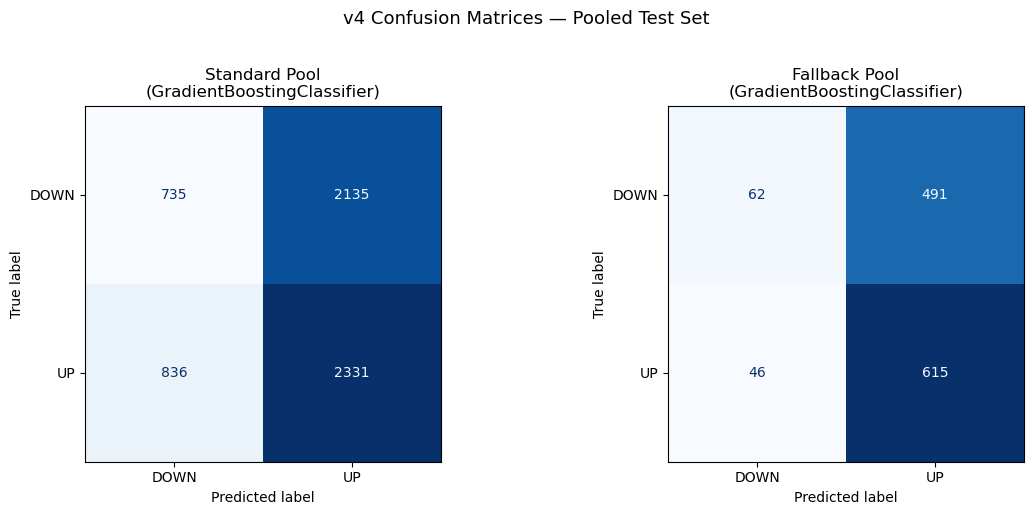

In [17]:
# ── 4.3 Confusion matrices ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, model, X_te, y_te) in zip(axes, [
    (f"Standard Pool\n({type(v4_std_model).__name__})", v4_std_model, X_te_std_v4, y_te_std_v4),
    (f"Fallback Pool\n({type(v4_fb_model).__name__})",  v4_fb_model,  X_te_fb_v4,  y_te_fb_v4),
]):
    cm   = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=["DOWN", "UP"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(label, fontsize=12)

plt.suptitle("v4 Confusion Matrices — Pooled Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Key Findings (version 4)

**RandomForestClassifier** wins the standard pool: **50.65% accuracy, F1=0.613**.  
**GradientBoostingClassifier** wins the fallback pool: **54.04% accuracy, F1=0.675**.

Both models exhibit a strong **UP bias**:

| Pool | Model | UP recall | DOWN recall |
|---|---|---|---|
| Standard | RFC | 0.75 | 0.24 |
| Fallback | GBC | 0.88 | 0.14 |

Root cause: stock markets trend upward over 2020–2024 (~52% UP days in the training data).  
Both models exploit this structural bias: they predict UP on most days, accumulating recall  
on UP but failing heavily on DOWN. SELL signals are therefore less reliable than BUY signals.

The confidence gate (`predict_proba < 0.52 → HOLD`) in `strategy.py` partially mitigates this  
by requiring minimum confidence before issuing any signal.

---
## Section 5 — Signal Generation

`model/strategy.py` is the single source of truth for signal conversion.  
It is imported by both this notebook and `app/pages/go_live.py` to guarantee consistency.

**Signal logic:**

```python
confidence = max(predict_proba(x))   # highest class probability
if confidence < 0.52:   → HOLD       # low-confidence prediction
elif prediction == 1:   → BUY        # UP predicted with sufficient confidence
else:                   → SELL       # DOWN predicted with sufficient confidence
```

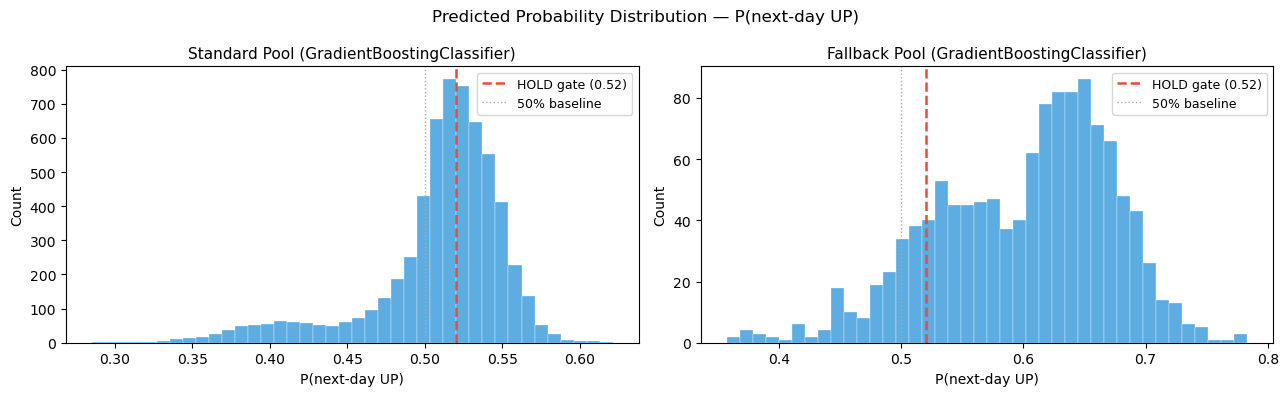

In [18]:
# ── 5.1 predict_proba distribution ────────────────────────────────────────────
#
# Shows how confident the classifier is across test rows.
# The vertical line at 0.52 is the HOLD gate in strategy.py.

from model.strategy import prediction_to_signal, Signal

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, model, X_te) in zip(axes, [
    (f"Standard Pool ({type(v4_std_model).__name__})", v4_std_model, X_te_std_v4),
    (f"Fallback Pool ({type(v4_fb_model).__name__})",  v4_fb_model,  X_te_fb_v4),
]):
    p_up = model.predict_proba(X_te)[:, 1]   # P(next-day UP)
    ax.hist(p_up, bins=40, edgecolor="white", linewidth=0.3, color="#3498db", alpha=0.8)
    ax.axvline(0.52, color="#e74c3c", linewidth=1.8, linestyle="--",
               label="HOLD gate (0.52)")
    ax.axvline(0.50, color="#aaaaaa", linewidth=1.0, linestyle=":",
               label="50% baseline")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("P(next-day UP)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Predicted Probability Distribution — P(next-day UP)", fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# ── 5.2 Signal distribution and accuracy on the test set ─────────────────────

for label, model, X_te, y_te in [
    ("standard", v4_std_model, X_te_std_v4, y_te_std_v4),
    ("fallback",  v4_fb_model,  X_te_fb_v4,  y_te_fb_v4),
]:
    preds    = model.predict(X_te)
    probas   = model.predict_proba(X_te).max(axis=1)   # confidence = max class proba
    signals  = pd.Series([prediction_to_signal(p, c).value for p, c in zip(preds, probas)])
    y_te_arr = y_te.values
    correct  = (preds == y_te_arr)                     # whether each prediction is correct

    vc    = signals.value_counts()
    total = len(signals)

    print(f"\n[{label.upper()} POOL]  n={total}  |  model={type(model).__name__}")
    print(f"  {'Signal':<6}  {'Count':>6}  {'Share':>7}  {'Acc on issued signals':>22}")
    print(f"  {'-'*48}")
    for sig in ["BUY", "HOLD", "SELL"]:
        n    = vc.get(sig, 0)
        mask = signals == sig
        acc_sig = correct[mask.values].mean() if mask.sum() > 0 else float("nan")
        acc_str = f"{acc_sig*100:.1f}%" if not np.isnan(acc_sig) else "—"
        print(f"  {sig:<6}  {n:>6}  {n/total*100:>6.1f}%  {acc_str:>22}")

    print(f"  HOLD gate removes predictions with max(proba) < 0.52")
    pct_held = (signals == "HOLD").mean() * 100
    print(f"  {pct_held:.1f}% of test rows converted to HOLD by confidence gate")


[STANDARD POOL]  n=6037  |  model=GradientBoostingClassifier
  Signal   Count    Share   Acc on issued signals
  ------------------------------------------------
  BUY       2854    47.3%                   53.2%
  HOLD      2240    37.1%                   49.2%
  SELL       943    15.6%                   47.2%
  HOLD gate removes predictions with max(proba) < 0.52
  37.1% of test rows converted to HOLD by confidence gate

[FALLBACK POOL]  n=1214  |  model=GradientBoostingClassifier
  Signal   Count    Share   Acc on issued signals
  ------------------------------------------------
  BUY       1032    85.0%                   55.1%
  HOLD       114     9.4%                   61.4%
  SELL        68     5.6%                   55.9%
  HOLD gate removes predictions with max(proba) < 0.52
  9.4% of test rows converted to HOLD by confidence gate


---
## Summary — ML Iteration Journey

| | v1 (OLS regression) | v2 (Ridge + LGBM) | v3 (dynamic thresholds) | v4 (classification) |
|---|---|---|---|---|
| **Problem type** | Regression | Regression | Regression | **Classification** |
| **Feature set** | 16 (w/ fundamentals) | 11 (no fundamentals) | 11 (unchanged) | 11 (unchanged) |
| **Standard train rows** | 22,148 | 24,201 | 24,201 | ~24,111 |
| **Models evaluated** | LR, RF, GBR | Ridge(CV), RF, GBR, LGBM | Same as v2 | **LogReg(CV), RFC, GBC, LGBM** |
| **Hyperparameter CV** | — | α via TimeSeriesSplit | Same as v2 | **C via TimeSeriesSplit** |
| **Winner (standard)** | LinearRegression | Ridge α=10 | Ridge α=10 | **RandomForestClassifier** |
| **Winner (fallback)** | LinearRegression | Ridge α=100 | Ridge α=100 | **GradientBoostingClassifier** |
| **Direction acc / accuracy** | ~49–50% | 50.67% / 51.44% | 50.67% / 51.44% | **50.65% / 54.04%** |
| **F1 (binary)** | — | — | — | **0.613 / 0.675** |
| **Signal distribution** | Not measured | **100% HOLD** (±0.5% band) | ~25% BUY / 50% HOLD / 25% SELL | UP-biased; HOLD gate via proba |
| **Key problem fixed** | Baseline | 100% HOLD exposed | HOLD fixed mechanically | **Direction optimised directly** |

### Open Issues

1. **UP bias** — RFC recall 0.75 UP vs 0.24 DOWN. SELL signals are unreliable.  
   Mitigation: `class_weight='balanced'` in LogisticRegression; consider asymmetric cost functions.

2. **Fundamental features disabled** — `Gross_Margin`, `Operating_Margin`, `Net_Margin`,  
   `Debt_to_Equity`, `Operating_CF_Ratio` are commented out in `model/strategy.py`.  
   Restore and retrain once the live API wrapper supplies quarterly data reliably.

3. **`backtest()` not implemented** — stub in `model/strategy.py` raises `NotImplementedError`.  
   A walk-forward backtest comparing v3 vs v4 signal P&L would be the next evaluation step.